In [33]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Data Loading - Using the FULL Melbourne Dataset
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/Melbourne_housing_FULL.csv"

try:
    df = pd.read_csv(url)
    print("✅ Data loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
except Exception as e:
    print(f"❌ Error loading data: {e}")

# Display first 5 rows
df.head()

✅ Data loaded successfully!
Dataset Shape: (34857, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [34]:
#checking for null values

df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,7610
Method,0
SellerG,0
Date,0
Distance,1
Postcode,1


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

In [36]:
# List of columns we want to keep
cols_to_use = [
    'Suburb', 'Rooms', 'Type', 'Method', 'SellerG', 'Regionname', 'Propertycount',
    'Distance', 'CouncilArea', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
    'BuildingArea','YearBuilt', 'Price'
]

# Create a subset of the dataframe
df = df[cols_to_use]

# Drop rows where Price is missing (our Target)
df = df.dropna(subset=['Price'])

print(f"New Shape: {df.shape}")
print("-" * 30)
print("Missing values per column now:")
print(df.isnull().sum())

New Shape: (27247, 16)
------------------------------
Missing values per column now:
Suburb               0
Rooms                0
Type                 0
Method               0
SellerG              0
Regionname           3
Propertycount        3
Distance             1
CouncilArea          3
Bedroom2          6441
Bathroom          6447
Car               6824
Landsize          9265
BuildingArea     16591
YearBuilt        15163
Price                0
dtype: int64


In [37]:
# 4. Fill missing numerical values with Median
cols_to_fix = ['BuildingArea', 'Landsize', 'YearBuilt', 'Bathroom', 'Car', 'Bedroom2']
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

In [38]:
df.isnull().sum()

,0
Suburb,0
Rooms,0
Type,0
Method,0
SellerG,0
Regionname,3
Propertycount,3
Distance,1
CouncilArea,3
Bedroom2,0


In [39]:
# 5. One-Hot Encoding (Only on the specific categorical columns)
df = pd.get_dummies(df, columns=['Type', 'Method', 'Regionname'], drop_first=True)

In [40]:
df.isnull().sum()

,0
Suburb,0
Rooms,0
SellerG,0
Propertycount,3
Distance,1
CouncilArea,3
Bedroom2,0
Bathroom,0
Car,0
Landsize,0


In [41]:
# 1. Fill ALL remaining numerical nulls with their respective medians
# This catches Postcode, Propertycount, Distance, etc.
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.median()))

# 2. Explicitly drop the columns that are still text
cols_to_drop = ['Suburb', 'SellerG', 'CouncilArea']
df_final = df.drop(columns=cols_to_drop, errors='ignore')

# 3. Final check - This MUST show all 0s
print("Missing values check:")
print(df_final.isnull().sum().sum())

# 4. Separate X and y
X = df_final.drop('Price', axis=1)
y = df_final['Price']

# 5. Split and Scale
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ SUCCESS: 0 missing values remain. Scaling complete!")


Missing values check:
0
✅ SUCCESS: 0 missing values remain. Scaling complete!


In [43]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# 1. Standard Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
print(f"Linear Reg Score: {lin_reg.score(X_test_scaled, y_test):.4f}")

# 2. Ridge Regression (L2 - Helps with large coefficients)
ridge_reg = Ridge(alpha=50)
ridge_reg.fit(X_train_scaled, y_train)
print(f"Ridge Reg Score:  {ridge_reg.score(X_test_scaled, y_test):.4f}")

# 3. Lasso Regression (L1 - Can set useless features to zero)
lasso_reg = Lasso(alpha=50, max_iter=1000)
lasso_reg.fit(X_train_scaled, y_train)
print(f"Lasso Reg Score:  {lasso_reg.score(X_test_scaled, y_test):.4f}")


Linear Reg Score: 0.5747
Ridge Reg Score:  0.5747
Lasso Reg Score:  0.5747


In [44]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest
# n_estimators=100 means we are using 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=2)

# 2. Train the model
rf_model.fit(X_train_scaled, y_train)

# 3. Score the model
rf_train_score = rf_model.score(X_train_scaled, y_train)
rf_test_score = rf_model.score(X_test_scaled, y_test)

print(f"Random Forest Training Score: {rf_train_score:.4f}")
print(f"Random Forest Testing Score:  {rf_test_score:.4f}")

Random Forest Training Score: 0.9510
Random Forest Testing Score:  0.7707


/tmp/ipykernel_12935/1005467387.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


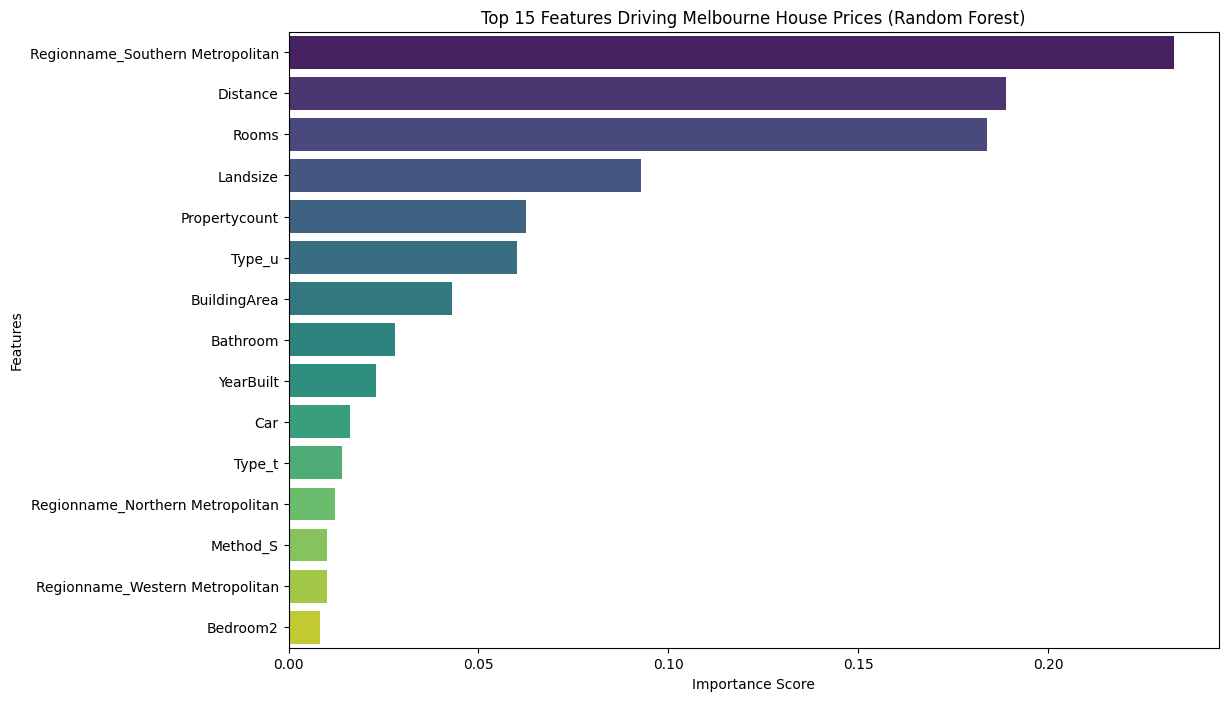

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importance values from our Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title("Top 15 Features Driving Melbourne House Prices (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [46]:
import joblib

# 1. Save the new high-performance model
joblib.dump(rf_model, 'melbourne_rf_model.pkl')

# 2. Save the same scaler and column list (we must keep these consistent)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')

print("✅ SUCCESS: Random Forest Model saved!")



✅ SUCCESS: Random Forest Model saved!


In [47]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 54.3 MB/s eta 0:00:00


In [48]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# 1. Load the artifacts we just created
model = joblib.load('melbourne_rf_model.pkl')
scaler = joblib.load('scaler.pkl')
model_columns = joblib.load('model_columns.pkl')

st.title("🏠 Melbourne House Price Predictor")

# 2. Input UI
rooms = st.slider("Number of Rooms", 1, 10, 3)
distance = st.number_input("Distance from CBD (km)", 0.0, 50.0, 10.0)
landsize = st.number_input("Landsize (m²)", 0, 10000, 500)
building_area = st.number_input("Building Area (m²)", 0, 5000, 150)
year_built = st.number_input("Year Built", 1800, 2026, 1970)

region = st.selectbox("Select Region", [
    'Southern Metropolitan', 'Northern Metropolitan', 'Western Metropolitan',
    'Eastern Metropolitan', 'South-Eastern Metropolitan', 'Eastern Victoria',
    'Northern Victoria', 'Western Victoria'
])

# 3. Prediction logic
if st.button("Calculate Price"):
    input_df = pd.DataFrame(0, index=[0], columns=model_columns)

    # Map inputs to the right columns
    input_df['Rooms'] = rooms
    input_df['Distance'] = distance
    input_df['Landsize'] = landsize
    input_df['BuildingArea'] = building_area
    input_df['YearBuilt'] = year_built

    region_col = f"Regionname_{region}"
    if region_col in model_columns:
        input_df[region_col] = 1

    # Scale and predict
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)[0]

    st.header(f"Estimated Value: ${prediction:,.2f}")

Writing app.py


In [53]:
!pip install pyngrok

In [54]:
import os
from google.colab import userdata
from pyngrok import ngrok
import subprocess

# 1. Pull the secret key securely from the notebook's environment
# Change 'NGROK_AUTH' to whatever you named your secret
try:
    NGROK_TOKEN = userdata.get('NGROK_AUTH')
    ngrok.set_auth_token(NGROK_TOKEN)
    print("✅ Secret key loaded successfully!")
except Exception as e:
    print(f"❌ Could not find secret: {e}")

# 2. Clean up any old sessions
ngrok.kill()
os.system("pkill streamlit")

# 3. Launch the App
try:
    # Run Streamlit in the background
    subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

    # Create the public tunnel
    public_url = ngrok.connect(8501).public_url
    print(f"\n🚀 YOUR APP IS LIVE!")
    print(f"Click here to view: {public_url}")
except Exception as e:
    print(f"❌ Connection Failed: {e}")

✅ Secret key loaded successfully!

🚀 YOUR APP IS LIVE!
Click here to view: https://cocciferous-dioicous-gino.ngrok-free.dev
